# Visium Spatial Transcriptomics Analysis (QC & Preprocessing)

10x Genomics Visium(표준 55µm spot) 유방암 FFPE 데이터 전처리.

Xenium(single-cell resolution, 377개 타깃 패널)과의 차이:
- Visium은 spot 하나에 여러 세포가 섞여 있음 (다세포 혼합, spot ≠ cell)
- whole transcriptome을 측정하므로 유전자 수가 훨씬 많고, 이후 분석 전에 **HVG(highly
  variable genes) 선택**이 필요함 (Xenium은 애초에 타깃 패널만 측정하므로 이 단계가 없었음)

이 노트북은 데이터 로드 → QC → normalization → HVG 선택까지만 다룬다.

In [1]:
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scanpy as sc
import squidpy as sq

/data1/home/woodg/miniconda3/envs/spatial/lib/python3.11/site-packages/docrep/decorators.py:43: SyntaxWarning: 'n_jobs' is not a valid key!
  doc = func(self, args[0].__doc__, *args[1:], **kwargs)
/data1/home/woodg/miniconda3/envs/spatial/lib/python3.11/site-packages/docrep/decorators.py:43: SyntaxWarning: 'show_progress_bar' is not a valid key!
  doc = func(self, args[0].__doc__, *args[1:], **kwargs)


## 0. 데이터 로드

Visium 데이터 경로 지정. 폴더 안에 filtered feature-barcode matrix(.h5)와
`spatial/`(tissue position, scale factor, 이미지) 폴더가 함께 있어야 한다.

In [2]:
# Visium 원본 데이터 디렉토리 (Space Ranger 출력 폴더: h5 파일 + spatial/ 폴더 포함)
DATA_DIR = "/data2/projects/2025_heartfailure/spatial_tme/visium_breast/"
COUNT_FILE = "Visium_FFPE_Human_Breast_Cancer_filtered_feature_bc_matrix.h5"

In [3]:
# read_visium은 h5(filtered feature-barcode matrix) + spatial/ 폴더(좌표, 이미지, scale factor)를
# 함께 읽어 adata.obsm["spatial"]과 adata.uns["spatial"]에 채워준다.
adata = sc.read_visium(DATA_DIR, count_file=COUNT_FILE)
# 유전자 심볼 중복 방지 (동일 symbol이 다른 Ensembl ID를 가리키는 경우가 있음)
adata.var_names_make_unique()

/tmp/ipykernel_3267878/3375713366.py:3: FutureWarning: Use `squidpy.read.visium` instead.
  adata = sc.read_visium(DATA_DIR, count_file=COUNT_FILE)


/data1/home/woodg/miniconda3/envs/spatial/lib/python3.11/site-packages/anndata/_core/anndata.py:1884: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


/data1/home/woodg/miniconda3/envs/spatial/lib/python3.11/site-packages/anndata/_core/anndata.py:1884: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [4]:
# 스팟 수 x 유전자 수 확인 (기대: 스팟 2,518 / 유전자는 whole transcriptome 규모)
print(adata.shape)

(2518, 17943)


In [5]:
# Space Ranger가 만든 metrics_summary.csv의 공식 집계치와 로딩 결과를 대조
metrics = pd.read_csv(DATA_DIR + "Visium_FFPE_Human_Breast_Cancer_metrics_summary.csv")
n_spots_expected = int(metrics["Number of Spots Under Tissue"].iloc[0])
n_genes_expected = int(metrics["Genes Detected"].iloc[0])

print(f"adata: {adata.n_obs} spots x {adata.n_vars} genes")
print(f"metrics_summary.csv: {n_spots_expected} spots under tissue, {n_genes_expected} genes detected")
assert adata.n_obs == n_spots_expected, "spot 수가 metrics_summary.csv와 다름"
# 주의: adata.n_vars는 filtered feature matrix에 실려 있는 전체 feature 수이고,
# metrics_summary.csv의 "Genes Detected"는 그 중 실제로 하나 이상의 카운트가 찍힌 유전자 수이므로
# 완전히 같은 정의가 아닐 수 있다 (n_vars >= genes_expected가 정상).

adata: 2518 spots x 17943 genes
metrics_summary.csv: 2518 spots under tissue, 17651 genes detected


## 1. Quality Control

In [6]:
# 미토콘드리아 유전자 플래그: 사람 유전자 심볼은 "MT-"로 시작 (예: MT-CO1, MT-ND1)
# (검증) 이 패널은 애초에 미토콘드리아 유전자를 포함하지 않는다 — 아래처럼 알려진 13개
# MT 단백질 코딩 유전자 심볼("MT-ND1" 등 및 대안 표기 "ND1" 등)과 그 Ensembl ID
# (예: MT-ND1 = ENSG00000198888)로 직접 조회해도 매칭이 0건이었음. 즉 표기 문제가
# 아니라 이 probe-based Visium FFPE whole-transcriptome panel 설계 자체에서 미토콘드리아
# 유전자가 제외되어 있는 것 (fresh-frozen polyA 캡처 기반 Visium과의 차이).
adata.var["mt"] = adata.var_names.str.startswith("MT-")
print(f"미토콘드리아 유전자 수: {adata.var['mt'].sum()}")

sc.pp.calculate_qc_metrics(adata, qc_vars=["mt"], inplace=True, percent_top=None)

미토콘드리아 유전자 수: 0


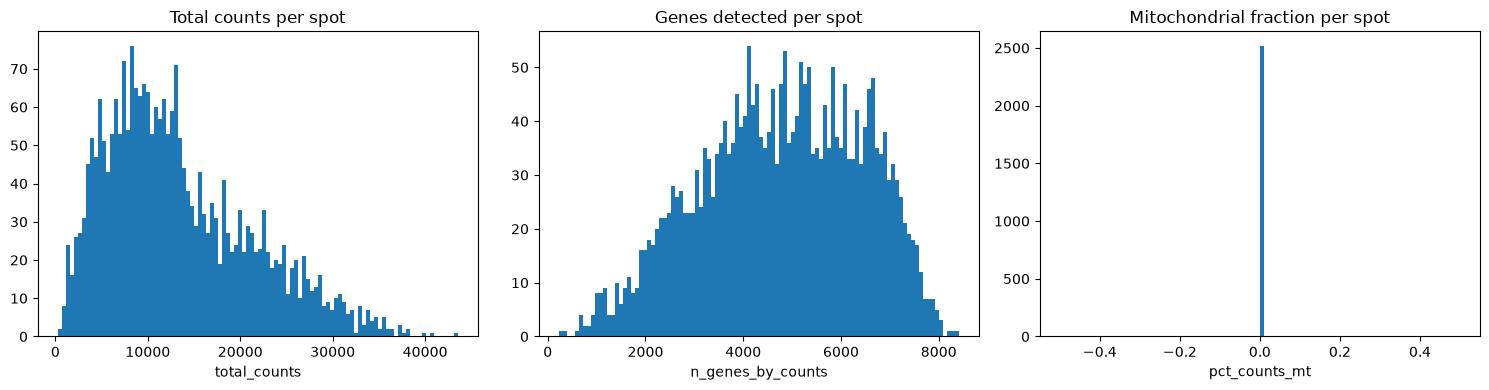

In [7]:
# spot별 total_counts, n_genes_by_counts, pct_counts_mt 분포 시각화
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(adata.obs["total_counts"], bins=100)
axes[0].set_title("Total counts per spot")
axes[0].set_xlabel("total_counts")

axes[1].hist(adata.obs["n_genes_by_counts"], bins=100)
axes[1].set_title("Genes detected per spot")
axes[1].set_xlabel("n_genes_by_counts")

axes[2].hist(adata.obs["pct_counts_mt"], bins=100)
axes[2].set_title("Mitochondrial fraction per spot")
axes[2].set_xlabel("pct_counts_mt")

plt.tight_layout()
plt.show()

### 저품질 스팟 필터링

컷오프를 임의로 먼저 정하지 않는다. 아래 분위수(quantile)로 이 데이터셋의 실제 분포를
먼저 확인한 뒤, 그 결과에 근거해 `MIN_COUNTS` / `MIN_GENES` 값을 정하고,
**왜 그 값을 선택했는지 다음 코드 셀의 주석으로 근거를 남긴다.**

참고: 위 히스토그램에서 `pct_counts_mt`가 전부 0으로 나오는데, 이는 필터링 버그가 아니라
이 데이터가 FFPE probe-based whole-transcriptome panel(Visium FFPE, 17,943개 probe 대상
유전자)이기 때문이다 — 이 probe set은 애초에 미토콘드리아 유전자를 포함하지 않는다
(polyA 캡처 기반 fresh-frozen Visium과의 차이). 따라서 이번 필터링에는 mt 비율을 기준으로
쓰지 않는다.

In [8]:
# 컷오프 결정에 참고할 분위수 확인
adata.obs[["total_counts", "n_genes_by_counts", "pct_counts_mt"]].quantile(
    [0.01, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9]
)

,total_counts,n_genes_by_counts,pct_counts_mt
0.01,1388.21,1058.17,0.0
0.05,3138.20,1974.85,0.0
0.10,4304.20,2506.70,0.0
0.25,7337.75,3596.00,0.0
0.50,11727.00,4840.50,0.0
0.75,18263.25,6091.00,0.0
0.90,24917.60,6902.30,0.0


In [9]:
# 위 분위수 결과 (total_counts / n_genes_by_counts) 기준으로 컷오프를 정한다.
#   - 1%ile: total_counts ~1388,  n_genes_by_counts ~1058
#   - 5%ile: total_counts ~3138,  n_genes_by_counts ~1975
# 이 데이터는 이미 Space Ranger가 "filtered" (tissue 아래 spot만 남긴) 행렬이라
# 극단적으로 낮은 spot은 거의 없다. 5%ile 부근에서 반올림한 값을 하한선으로 사용해
# 분포의 최하위 꼬리(약 5%)만 제거하는 보수적인 필터를 적용한다.
# pct_counts_mt는 이 probe panel에 미토콘드리아 유전자가 없어 전부 0이므로 필터 기준에서 제외.
MIN_COUNTS = 3000
MIN_GENES = 2000

n_before = adata.n_obs
sc.pp.filter_cells(adata, min_counts=MIN_COUNTS)
sc.pp.filter_cells(adata, min_genes=MIN_GENES)
print(f"필터링 전: {n_before} spots -> 필터링 후: {adata.n_obs} spots "
      f"({n_before - adata.n_obs}개 제거, {(n_before - adata.n_obs) / n_before:.1%})")

필터링 전: 2518 spots -> 필터링 후: 2388 spots (130개 제거, 5.2%)


In [10]:
# 원본(raw) count를 layers에 보관 — 이후 일부 분석(예: 특정 LR/DE 방법)이 raw count를 요구할 수 있음
adata.layers["counts"] = adata.X.copy()

In [11]:
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)
print(adata)

AnnData object with n_obs × n_vars = 2388 × 17943
    obs: 'in_tissue', 'array_row', 'array_col', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_counts', 'n_genes'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    uns: 'spatial', 'log1p'
    obsm: 'spatial'
    layers: 'counts'


## 2. Highly Variable Genes

Xenium은 377개 유전자로 구성된 타깃 패널이라 유전자를 추가로 추릴 필요가 없었지만,
Visium은 whole transcriptome(수만 개 유전자)을 측정하므로 이후 PCA/클러스터링 등에서
노이즈가 큰 유전자를 걸러내기 위해 **HVG(highly variable genes) 선택**이 필요하다.

In [12]:
# seurat_v3 flavor는 raw count(layers["counts"])를 입력으로 사용하는 방식이 권장되지만,
# 여기서는 scanpy 기본(seurat) flavor로 log1p 정규화된 adata.X 기준 분산을 사용한다.
sc.pp.highly_variable_genes(adata, n_top_genes=2000)
print(f"HVG로 선택된 유전자 수: {adata.var['highly_variable'].sum()}")

HVG로 선택된 유전자 수: 2000


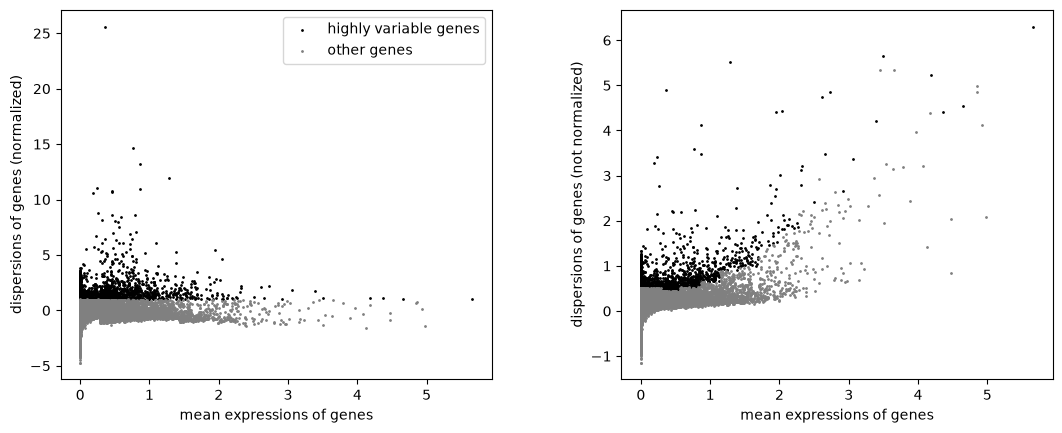

In [13]:
sc.pl.highly_variable_genes(adata)

## 3. Clustering & Spatial Domains

Xenium은 single-cell resolution이라 클러스터가 곧 개별 세포 유형에 대응했지만,
Visium spot은 여러 세포가 섞인 다세포 혼합 단위이므로 여기서 얻는 leiden 클러스터는
**"세포 유형"이 아니라 "공간 도메인"(spatial domain)** 으로 해석해야 한다 — 즉 비슷한
세포 조성/발현 패턴을 공유하는 조직 내 영역(niche에 가까운 개념)이지, 하나의 세포 종류를
가리키는 것이 아니다.

PCA는 QC 필터링 이후 계산한 HVG(2000개) 기반으로 수행한다.

In [14]:
# HVG(2000개)만 사용해 PCA 계산 — whole transcriptome 전체를 다 쓰지 않고
# 분산이 큰 유전자만 사용해 노이즈를 줄인다 (Xenium은 타깃 패널 전체를 그대로 사용했던 것과 대비)
sc.pp.pca(adata, use_highly_variable=True)

/data1/home/woodg/miniconda3/envs/spatial/lib/python3.11/site-packages/scanpy/preprocessing/_pca/__init__.py:226: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  mask_var_param, mask_var = _handle_mask_var(


In [15]:
# PCA 결과 기반 kNN 그래프 생성 (leiden 클러스터링과 UMAP의 입력)
sc.pp.neighbors(adata)

In [16]:
# Leiden 클러스터링 resolution. 값이 클수록 도메인이 더 세분화된다.
# 공간 도메인이 너무 잘게 쪼개지면 낮추고, 너무 뭉뚱그려지면 높인다.
LEIDEN_RES = 1.0

# flavor="igraph", n_iterations=2, directed=False는 scanpy가 권장하는 최신 설정
# (기존 기본값 flavor="leidenalg"는 향후 deprecated 예정)
sc.tl.leiden(
    adata,
    resolution=LEIDEN_RES,
    flavor="igraph",
    n_iterations=2,
    directed=False,
)
print(f"클러스터(공간 도메인) 수: {adata.obs['leiden'].nunique()}")

클러스터(공간 도메인) 수: 15


In [17]:
# UMAP 임베딩 (neighbors 그래프 필요)
sc.tl.umap(adata)

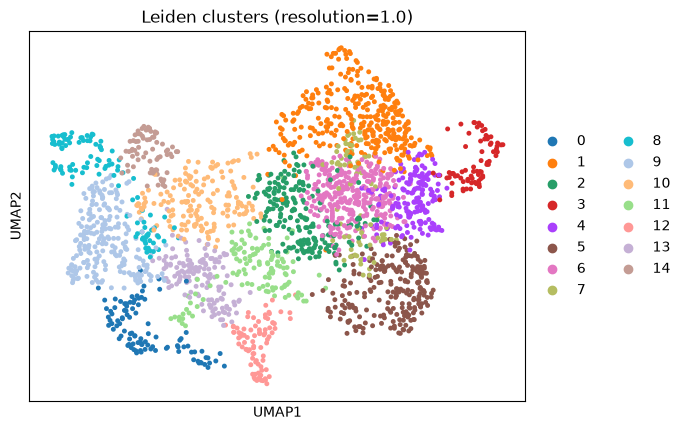

In [18]:
# UMAP에 leiden 클러스터를 색칠하여 클러스터 분리도 확인
sc.pl.umap(adata, color="leiden", title=f"Leiden clusters (resolution={LEIDEN_RES})")

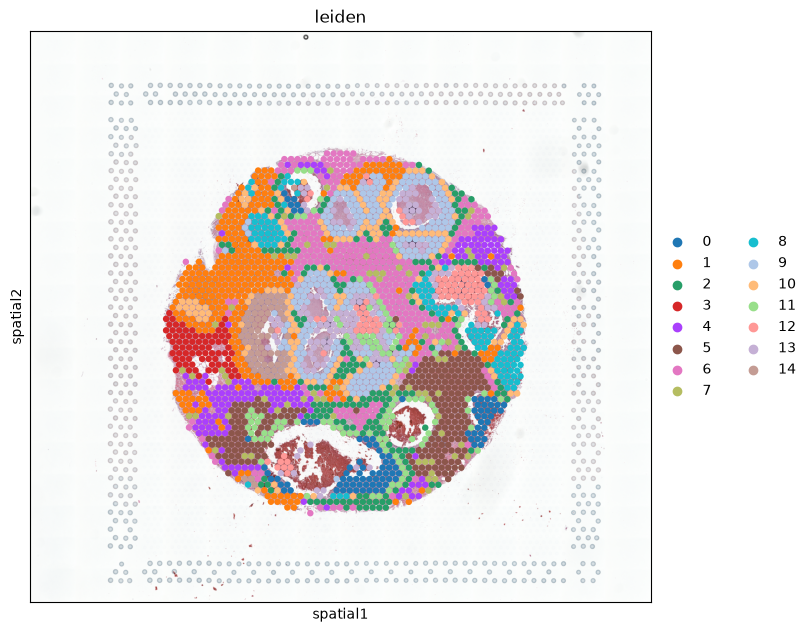

In [19]:
# 실제 조직 공간 좌표에 동일한 클러스터를 뿌려 공간 도메인 분포 확인.
# Visium은 H&E 이미지가 함께 있으므로 img=True로 이미지 위에 오버레이한다
# (이미지가 없었던 Xenium 노트북의 img=False 설정과 대비).
sq.pl.spatial_scatter(
    adata,
    color="leiden",
    img=True,
    size=1.5,
    figsize=(8, 8),
)

### 해석

위 UMAP과 공간 플롯에 나타난 leiden 클러스터는 Xenium 노트북의 세포 클러스터처럼
"세포 유형"을 의미하지 않는다. 각 spot이 다세포 혼합이므로, 클러스터는 **유사한 세포
조성·발현 패턴을 공유하는 조직 내 공간 도메인**을 나타낸다. 예를 들어 종양 세포 비중이
높은 도메인, 기질/면역세포가 섞인 도메인처럼 조직학적 영역 단위로 해석해야 하며,
개별 세포 유형 라벨을 붙이려면 deconvolution 등 추가 분석이 필요하다.

## 4. 체크포인트 저장

QC 필터링, normalization, HVG, 공간 도메인 클러스터링까지 끝난 상태의 adata를
h5ad로 저장해 이후 분석(니치/이웃 분석 등)에서 이 지점부터 다시 시작할 수 있게 한다.

In [20]:
CHECKPOINT_PATH = "/data2/projects/2025_heartfailure/spatial_tme/visium_breast/adata_visium_clustered.h5ad"
adata.write(CHECKPOINT_PATH)
print(f"저장 완료: {CHECKPOINT_PATH}")

저장 완료: /data2/projects/2025_heartfailure/spatial_tme/visium_breast/adata_visium_clustered.h5ad
